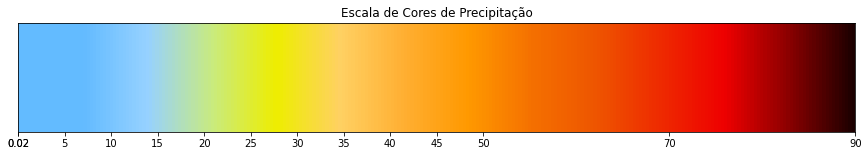

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Lista de cores com valores
alertario_precipitation_colors = [
    # {"value": 0, "color": None},  # "#cfcfcf"
    {"value": 0.02, "color": "#63bbff"},
    {"value": 0.02, "color": "#63bbff"},
    {"value": 5, "color": "#97d2ff"},
    {"value": 10, "color": "#c9eb80"},
    {"value": 15, "color": "#eeee00"},
    {"value": 20, "color": "#ffd163"},
    {"value": 25, "color": "#ffaf32"},
    {"value": 30, "color": "#ff9900"},
    {"value": 35, "color": "#f57000"},
    {"value": 40, "color": "#ee5500"},
    {"value": 45, "color": "#ee2a00"},
    {"value": 50, "color": "#ee0000"},
    {"value": 70, "color": "#8a0000"},
    {"value": 90, "color": "#1c0000"},
]

# Extraindo valores e cores
values = [entry["value"] for entry in alertario_precipitation_colors]
colors = [entry["color"] for entry in alertario_precipitation_colors]

# Criar uma colormap usando as cores fornecidas
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Normalizar os valores para o intervalo [0, 1]
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))

# Criar o gradiente de cores
gradient = np.linspace(0, 1, 256).reshape(1, -1)

# Plotar a escala de cores
fig, ax = plt.subplots(figsize=(15, 2))
ax.imshow(gradient, aspect="auto", cmap=cmap, extent=[min(values), max(values), 0, 1])

# Adicionar rótulos
ax.set_xticks(values)
ax.set_xticklabels(values)
ax.set_yticks([])
ax.set_title("Escala de Cores de Precipitação", fontsize=12)

plt.show()

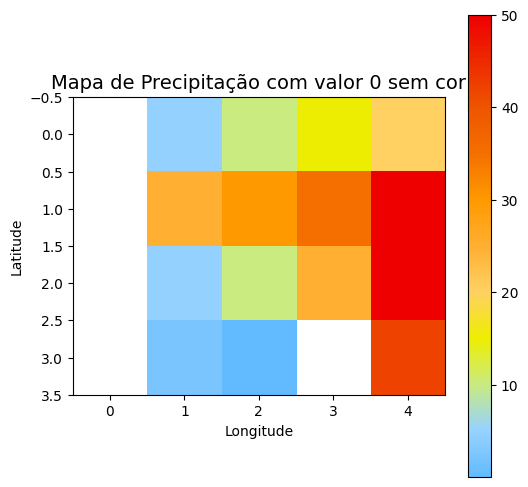

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Lista de cores com None para o valor 0
alertario_precipitation_colors = [
    {"value": 0, "color": None},  # Nenhuma cor para o valor 0
    {"value": 0.02, "color": "#63bbff"},
    {"value": 5, "color": "#97d2ff"},
    {"value": 10, "color": "#c9eb80"},
    {"value": 15, "color": "#eeee00"},
    {"value": 20, "color": "#ffd163"},
    {"value": 25, "color": "#ffaf32"},
    {"value": 30, "color": "#ff9900"},
    {"value": 35, "color": "#f57000"},
    {"value": 40, "color": "#ee5500"},
    {"value": 45, "color": "#ee2a00"},
    {"value": 50, "color": "#ee0000"},
]

# Filtrar cores que não são None
filtered_colors = [
    (entry["value"], entry["color"])
    for entry in alertario_precipitation_colors
    if entry["color"] is not None
]

values, colors = zip(*filtered_colors)

# Criar uma colormap usando as cores filtradas
cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)

# Normalizar os valores para o intervalo [0, 1]
norm = mcolors.Normalize(vmin=min(values), vmax=max(values))

# Fake array
data = np.array(
    [
        [0, 5, 10, 15, 20],
        [0, 25, 30, 35, 60],
        [0, 5, 10, 25, 50],
        [0, 2.5, 0.1, 0.01, 42],
    ]
)


# Replace values lesser than 0.02 to NaN
data[data < 0.02] = np.nan

# Lets set a up threshold on 50
data[data > 50] = 50

fig, ax = plt.subplots(figsize=(6, 6))

cbar = ax.imshow(data, cmap=cmap, norm=norm)
fig.colorbar(cbar, ax=ax, orientation="vertical")

ax.set_title("Mapa de Precipitação com valor 0 sem cor", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

['#63bbff', '#91ccab', '#bfdd56', '#eeee01', '#ffff00', '#ffaf32', '#ff9b00', '#f57000', '#ee5500', '#ee2a00', '#ED0000', '#d40000', '#bc0000', '#a30000', '#8A0000', '#6e0000', '#530000', '#380000', '#1C0000']


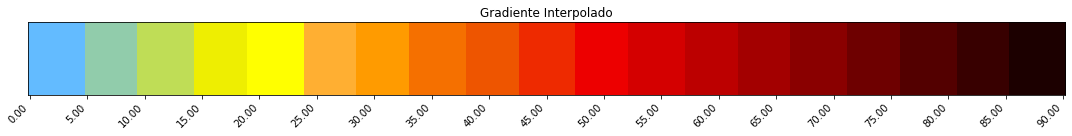

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgb, to_hex

# Escala inicial
scale = {
    0.02: "#63BBFF",  # Azul claro
    15.05: "#EEEE00",  # Amarelo,
    # 20: "#ffd163",
    25: "#ffaf32",
    27.55: "#FFA500",  # Laranja
    35: "#f57000",
    40:"#ee5500",
    50: "#ED0000",     # Vermelho
    70: "#8A0000",     # Vermelho escuro
    90: "#1C0000"      # Marrom escuro
}

# Criar ranges de 5 em 5
min_value = min(scale.keys())
max_value = max(scale.keys())
ranges = np.arange(0, max_value + 5, 5)

# Função para interpolar cores
def interpolate_color(val, v_min, v_max, c_min, c_max):
    ratio = (val - v_min) / (v_max - v_min)
    rgb_min = np.array(to_rgb(c_min))  # Garantir que está em [0, 1]
    rgb_max = np.array(to_rgb(c_max))
    interpolated_rgb = rgb_min + ratio * (rgb_max - rgb_min)
    interpolated_rgb = np.clip(interpolated_rgb, 0, 1)  # Certificar que está no intervalo [0, 1]
    return to_hex(interpolated_rgb)

# Interpolar cores para os ranges
result = {}
previous_value = min_value
previous_color = scale[previous_value]

for current_value in ranges:
    if current_value in scale:
        current_color = scale[current_value]
    else:
        # Encontrar o intervalo onde current_value se encaixa
        next_value = min([v for v in scale.keys() if v > previous_value])
        next_color = scale[next_value]
        current_color = interpolate_color(current_value, previous_value, next_value, previous_color, next_color)
    result[current_value] = current_color
    if current_value in scale:
        previous_value = current_value
        previous_color = scale[previous_value]

# Preparar os dados para o gradiente
colors = [result[value] for value in ranges]
cmap = ListedColormap(colors)
print(colors)

# Criar o plot
fig, ax = plt.subplots(figsize=(15, 2))
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cmap)
ax.set_xticks(np.linspace(0, 255, len(ranges)))
ax.set_xticklabels([f"{value:.2f}" for value in ranges], rotation=45, ha="right")
ax.set_yticks([])

ax.set_title("Gradiente Interpolado", fontsize=12)
plt.tight_layout()
plt.show()


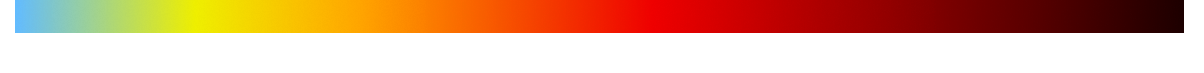

In [21]:
result

{0: '#63bbff',
 5: '#91ccab',
 10: '#bfdd56',
 15: '#eeee01',
 20: '#ffd163',
 25: '#ffb421',
 30: '#ff9700',
 35: '#f57000',
 40: '#ee5500',
 45: '#ee2a00',
 50: '#ED0000',
 55: '#d40000',
 60: '#bc0000',
 65: '#a30000',
 70: '#8A0000',
 75: '#6e0000',
 80: '#530000',
 85: '#380000',
 90: '#1C0000'}

In [ ]:
result

____
____

# Esse aqui extrai as cores direto da imagem

In [24]:
from PIL import Image
import numpy as np

# Carregar a imagem
image_path = "colorbar.png"  # Atualize o caminho, se necessário
image = Image.open(image_path)

# Converter para RGB (caso não esteja)
image = image.convert("RGB")

# Definir uma linha de amostragem (linha central da imagem)
height = image.height // 2  # Linha central
width = image.width
pixels = np.array(image)  # Converter a imagem em matriz de pixels

# Pegar valores a cada intervalo de 5 unidades na escala horizontal
interval = width // (90 // 5)  # Dividir a escala em intervalos de 5
sampled_colors = []

for x in range(0, width, interval):
    rgb = pixels[height, x]  # Pegamos a cor no ponto (x, linha central)
    hex_color = "#{:02x}{:02x}{:02x}".format(*rgb)  # Converter RGB para HEX
    sampled_colors.append((x, hex_color))

# Mostrar os valores extraídos
for position, color in sampled_colors:
    print(f"Posição: {position}, Cor: {color}")


Posição: 0, Cor: #61b5f4
Posição: 37, Cor: #95cda3
Posição: 74, Cor: #c8e046
Posição: 111, Cor: #efe700
Posição: 148, Cor: #f6ca00
Posição: 185, Cor: #fdae00
Posição: 222, Cor: #fc8c00
Posição: 259, Cor: #f96700
Posição: 296, Cor: #f44300
Posição: 333, Cor: #f11f00
Posição: 370, Cor: #eb0000
Posição: 407, Cor: #d20000
Posição: 444, Cor: #b80000
Posição: 481, Cor: #9f0000
Posição: 518, Cor: #860000
Posição: 555, Cor: #6b0000
Posição: 592, Cor: #510000
Posição: 629, Cor: #390000
Posição: 666, Cor: #200000


In [25]:
ranges

array([ 0,  5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80,
       85, 90])

['#61b5f4', '#95cda3', '#c8e046', '#efe700', '#f6ca00', '#fdae00', '#fc8c00', '#f96700', '#f44300', '#f11f00', '#eb0000', '#d20000', '#b80000', '#9f0000', '#860000', '#6b0000', '#510000', '#390000', '#200000']


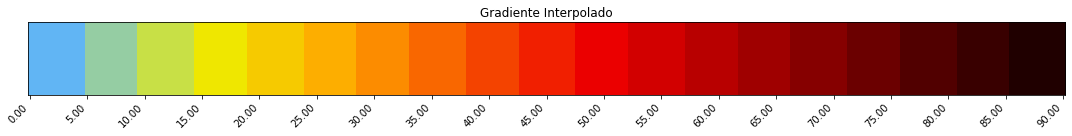

In [31]:
# Preparar os dados para o gradiente
colors = [i[1] for i in sampled_colors]
cmap = ListedColormap(colors)
print(colors)

# Criar o plot
fig, ax = plt.subplots(figsize=(15, 2))
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap=cmap)
ax.set_xticks(np.linspace(0, 255, len(ranges)))
ax.set_xticklabels([f"{value:.2f}" for value in ranges], rotation=45, ha="right")
ax.set_yticks([])

ax.set_title("Gradiente Interpolado", fontsize=12)
plt.tight_layout()
plt.show()


In [34]:
dict(zip(ranges, colors))

{0: '#61b5f4',
 5: '#95cda3',
 10: '#c8e046',
 15: '#efe700',
 20: '#f6ca00',
 25: '#fdae00',
 30: '#fc8c00',
 35: '#f96700',
 40: '#f44300',
 45: '#f11f00',
 50: '#eb0000',
 55: '#d20000',
 60: '#b80000',
 65: '#9f0000',
 70: '#860000',
 75: '#6b0000',
 80: '#510000',
 85: '#390000',
 90: '#200000'}

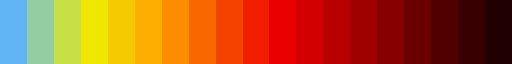

In [33]:
cmap